Board after move 1


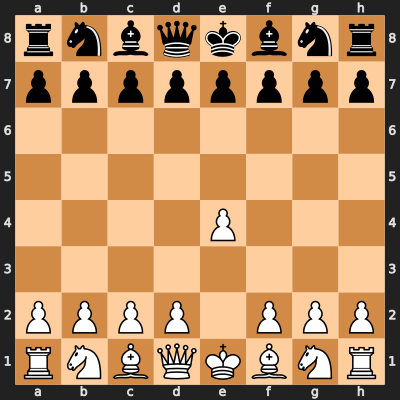

LMStudioTimeoutError: 

{"channel_id": 2, "event": "Received unhandled message {'type': 'channelSend', 'channelId': 2, 'message': {'type': 'promptProcessingProgress', 'progress': 0.62830841}} for already closed channel", "ws_url": "ws://127.0.0.1:41343/llm"}
{"channel_id": 2, "event": "Received unhandled message {'type': 'channelSend', 'channelId': 2, 'message': {'type': 'promptProcessingProgress', 'progress': 1}} for already closed channel", "ws_url": "ws://127.0.0.1:41343/llm"}
{"channel_id": 2, "event": "Received unhandled message {'type': 'channelSend', 'channelId': 2, 'message': {'type': 'toolCallGenerationStart', 'toolCallId': '351944218'}} for already closed channel", "ws_url": "ws://127.0.0.1:41343/llm"}
{"channel_id": 2, "event": "Received unhandled message {'type': 'channelSend', 'channelId': 2, 'message': {'type': 'toolCallGenerationNameReceived', 'name': 'legal_moves'}} for already closed channel", "ws_url": "ws://127.0.0.1:41343/llm"}
{"channel_id": 2, "event": "Received unhandled message {'type'

In [ ]:
import chess
import chess.polyglot
from IPython.display import display, SVG, clear_output
import random
import os, requests, shutil, pathlib

import lmstudio as lms
model = lms.llm("ibm-granite/granite-3.3-8b-instruct-GGUF")

board = chess.Board()

ai_pos = 0

# Download book moves
RAW_URL   = ("https://raw.githubusercontent.com/"
             "niklasf/python-chess/master/data/polyglot/performance.bin")
DEST_FILE = "performance.bin"

if not os.path.exists(DEST_FILE):
    print("Downloading performance.bin …")
    try:
        with requests.get(RAW_URL, stream=True, timeout=15) as r:
            r.raise_for_status()
            with open(DEST_FILE, "wb") as out:
                shutil.copyfileobj(r.raw, out, 1 << 16) 
    except requests.exceptions.RequestException as e:
        raise RuntimeError(f"Download failed: {e}")
    

def legal_moves() -> list[str]:
    """
    Returns a list of legal moves in standard algebraic notation.
    """
    return [board.san(move) for move in board.legal_moves]

def possible_captures()-> list[dict]:
    """
    Returns all legal captures with metadata:
    - san: SAN notation of the capture move.
    - captured_piece: The piece type being captured ('P','N','B','R','Q','K').
    - is_hanging: True if the captured piece was undefended before the capture.
    """

    result = []
    for move in board.generate_legal_captures():
        piece = board.piece_at(move.to_square)
        piece_type = piece.symbol().upper() if piece else "?"
        defenders = board.attackers(not board.turn, move.to_square)
        is_hanging = len(defenders) == 0

        result.append({
            "san": board.san(move),
            "captured_piece": piece_type,
            "is_hanging": is_hanging    
        })
    return result

def possible_checks() -> list[dict] :
    """
    Returns all legal checking moves with metadata:
    - san: SAN notation of the checking move.
    - can_be_captured: True if after the move, the checking piece can be captured.
    - can_be_blocked: True if the check can be legally blocked.
    - can_escape_by_moving_king: True if the king can move out of check.
    """
    result = []
    for move in board.legal_moves:
        if not board.gives_check(move):
            continue
        temp = board.copy()
        temp.push(move)

        can_capture = any(
            temp.is_capture(reply) and reply.to_square == move.to_square
            for reply in temp.legal_moves
         )
        
        # King escapes by moving
        king_sq = temp.king(not board.turn)
        can_escape = any(
            reply.from_square == king_sq for reply in temp.legal_moves
        )

        # Blocking: legal non-capture, non-king move that resolves check
        can_block = any(
            not temp.is_capture(reply)
            and reply.from_square != king_sq
            and not temp.gives_check(reply)
            for reply in temp.legal_moves
        )

        result.append({
            "san": board.san(move),
            "can_be_captured": can_capture,
            "can_be_blocked": can_block,
            "can_escape_by_moving_king": can_escape
        })
    return result

def get_move_history() -> list[str]:
    """
    Returns a list of moves made in the game so far in standard algebraic notation.
    """
    return [board.san(move) for move in board.move_stack]

def get_book_moves() -> list[str]:
    """
    Returns a list of book moves in standard algebraic notation from performance.bin
    for the current board position. If no book moves exist, returns an empty list.
    """
    moves = []
    with chess.polyglot.open_reader("performance.bin") as reader:
        for entry in reader.find_all(board):
            san_move = board.san(entry.move)
            moves.append(san_move)
    return moves

def is_ai_turn() -> bool:
    return bool(board.turn) == (ai_pos == 0)

def make_ai_move(move: str) -> None:
    """
    Given a string representing a valid move in chess notation, pushes move onto chess board.
    If non-valid move, raises a ValueError with message "Illegal move.
    If called when it is not the AI's turn, raises a ValueError with message "Not AI's turn."
    THIS FUNCTION DIRECTLY ENABLES THE AI TO MAKE A MOVE ON THE CHESS BOARD.
    """
    if is_ai_turn():
        try:
            board.push_san(move)
        except ValueError as e:
            raise ValueError(e)
    else:
        raise ValueError("Not AI's turn.")

def make_user_move(move: str) -> None:
    """
    Given a string representing a valid move in chess notation, pushes move onto chess board.
    If non-valid move, raises a ValueError with message "Illegal move.
    If called when it is not the player's turn, raises a ValueError with message "Not player's turn."
    If valid-move, updates the board and displays the current state of the board.
    """
    if not is_ai_turn():
        try:
            board.push_san(move)
        except ValueError as e:
            raise ValueError(e)
    else:
        raise ValueError("Not player's turn.")

def print_fragment(fragment, round_index=0):
    print(fragment.content, end="", flush=True)

chat_white = lms.Chat("""You are a chess AI, playing for white. Your task is to make the best move in the current position, using the provided tools. 
                      You should use your overall chess knowledge, including openings, tactics, and strategies, as your primary method to determine good moves. 
                      Use the provided tools as an assistant to improve your understanding of the board state and to make your moves. Always use the book moves 
                      if they are available. Be prudicious with your checks and captures. Understand whether the capturable piece is hanging, and its value in 
                      comparison to the piece you are using to capture. Consider the different ways the opponent can defend a check, to pick the best option.""")


chat_black = lms.Chat("""You are a chess AI, playing for black. Your task is to make the best move in the current position, using the provided tools. 
                      You should use your overall chess knowledge, including openings, tactics, and strategies, as your primary method to determine good moves. 
                      Use the provided tools as an assistant to improve your understanding of the board state and to make your moves. Always use the book moves 
                      if they are available. Be prudicious with your checks and captures. Understand whether the capturable piece is hanging, and its value in 
                      comparison to the piece you are using to capture. Consider the different ways the opponent can defend a check, to pick the best option.""")


move = 0
import chess.svg

board.reset()
ai_pos = round(random.random())

def update_board(move = move, ai_pos = ai_pos):
    """
    Updates the chess board display in the notebook.
    """
    clear_output(wait=True)  # Clear previous output
    print(f"Board after move {move+1}")
    if (ai_pos == 1):
        display(SVG(chess.svg.board(board, size=400)))
    else:
        display(SVG(chess.svg.board(board, size=400, orientation = chess.BLACK)))

def get_end_state():
    """
    Returns the end state of the chess game.
    """
    if board.is_checkmate():
        return "Checkmate!"
    elif board.is_stalemate():
        return "Stalemate!"
    elif board.is_insufficient_material():
        return "Draw by insufficient material!"
    elif board.is_seventyfive_moves():
        return "Draw by 75-move rule!"
    elif board.is_fivefold_repetition():
        return "Draw by fivefold repetition!"
    else:
        return None

clear_output(wait=True) # Clear any previous output from the cell
if (ai_pos == 1):
    display(SVG(chess.svg.board(board, size=400)))
else:
    display(SVG(chess.svg.board(board, size=400, orientation = chess.BLACK)))

# 2. Loop through moves, apply each move, clear previous output, and display new board
userEndGame = False
while True:

    if ai_pos == 0:
        # AI's turn
        model.act(
            chat_white,
            [get_move_history, legal_moves, possible_captures, possible_checks, get_book_moves, make_ai_move],
            on_message=print,
            max_prediction_rounds = 8,
        )


        if is_ai_turn(): # failsafe in case AI does not make a move
           make_ai_move(legal_moves()[0])  # Default to the first legal move if AI does not respond

        update_board(move)
        move += 1
        game_over_message = get_end_state()
        if game_over_message:
            print(game_over_message)
            break

        # User's turn
        while True:
            user_move = input("User (Playing Black): Input your move. Input 'help' to see the list of possible moves. Input 'quit' to end the game ->")
            if user_move.lower() == 'quit':
                print("Game ended by user.")
                userEndGame = True
                break
            if user_move.lower() == 'help':
                print("Possible moves:", legal_moves())
                continue
            try:
                make_user_move(user_move)
                break
            except ValueError as e:
                print(e)

        if userEndGame:
            break

        update_board(move)
        move += 1
        game_over_message = get_end_state()
        if game_over_message:
            print(game_over_message)
            break
    else:
        # User's turn
        while True:
            user_move = input("User (Playing White): Input your move. Input 'help' to see the list of possible moves. Input 'quit' to end the game ->")
            if user_move.lower() == 'quit':
                print("Game ended by user.")
                userEndGame = True
                break
            if user_move.lower() == 'help':
                print("Possible moves:", legal_moves())
                continue
            try:
                make_user_move(user_move)
                break
            except ValueError as e:
                print(e)

        if userEndGame:
            break

        update_board(move)
        move += 1
        game_over_message = get_end_state()
        if game_over_message:
            print(game_over_message)
            break

        model.act(
            chat_black,
            [get_move_history, legal_moves, possible_captures, possible_checks, get_book_moves, make_ai_move],
            max_prediction_rounds = 8,
            on_message=print,
        )

        if is_ai_turn(): # failsafe in case AI does not make a move
           make_ai_move(legal_moves()[0])  # Default to the first legal move if AI does not respond

        update_board(move)
        move += 1
        game_over_message = get_end_state()
        if game_over_message:
            print(game_over_message)
            break